<a href="https://colab.research.google.com/github/DmitryDudkin1987/Delivery_time/blob/main/%D0%A4%D0%B8%D0%BD%D0%B0%D0%BB%D1%8C%D0%BD%D1%8B%D0%B9_%D0%BF%D1%80%D0%BE%D0%B5%D0%BA%D1%82_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🚀 Финальный проект
## Прогнозирование времени доставки в сервисе доставки еды

### 📋 Описание задачи

Вы работаете Data Scientist в крупном сервисе доставки еды. Перед вами стоит важная задача — построить модель для **прогнозирования времени доставки заказа**.

**Почему это важно?**
- Точный прогноз времени позволяет устанавливать реалистичные ожидания у клиентов
- Помогает оптимизировать распределение курьеров
- Снижает количество негативных отзывов из-за задержек

**Что нужно сделать?**
1. Исследовать данные из разных источников (клиенты, курьеры, рестораны, погода, трафик)
2. Собрать итоговый датасет для обучения
3. Построить модель, предсказывающую **время доставки заказа** (в минутах)
4. Протестировать модель на свежих данных (oot) и проверить её стабильность

### 🎯 Критерии оценивания (максимум 17 баллов)

| Этап | Баллы | Что нужно сделать |
|------|-------|-------------------|
| **1. Сбор признаков (DWH)** | 1-3 | Объединить таблицы, создать признаки |
| **2. Разведочный анализ (EDA)** | 1-2 | Исследовать данные и связи с таргетом |
| **3. Предобработка** | 1-2 | Разделить данные по времени, обработать пропуски |
| **4. Baseline модель** | 1-3 | Обучить первую модель и оценить качество |
| **5. Эксперименты** | 1-4 | Улучшать модель, подбирать параметры |
| **6. Интерпретация** | 1-2 | Объяснить, что влияет на доставку |
| **7. Мониторинг** | 1 | Проверить сдвиг данных |

**Итого: до 17 баллов**


In [ ]:
import os
import requests
import pandas as pd
from sqlalchemy import create_engine

# URL к базе
url = "https://raw.githubusercontent.com/totiela/stepik_simulator_ds/main/lessons/final_project/delivery_final_homework.db"
local_path = "delivery_final_homework.db"

# Скачиваем файл, если его нет
if not os.path.exists(local_path):
    r = requests.get(url)
    r.raise_for_status()
    with open(local_path, "wb") as f:
        f.write(r.content)

# Подключение через SQLAlchemy
engine = create_engine(f"sqlite:///{local_path}")

In [ ]:
# Проверяем: выводим список таблиц
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", engine)
print("\n📊 Доступные таблицы в БД:")
for i, table in enumerate(tables['name'], 1):
    print(f"  {i}. {table}")


📊 Доступные таблицы в БД:
  1. customers
  2. couriers
  3. restaurants
  4. weather
  5. traffic
  6. orders


# 📊 Описание данных

База данных содержит **6 таблиц**, которые отражают разные аспекты работы сервиса доставки:

## 1. 👥 customers — информация о клиентах
- `customer_id` — уникальный идентификатор клиента
- `customer_city` — город регистрации клиента (город может не соответсвовать текущему месту проживания)
- `account_age_days` — сколько дней клиент пользуется сервисом
- `preferred_payment_method` — предпочтительный способ оплаты (card/cash/sbp)
- `mobile_os` — операционная система смартфона (iOS/Android)
- `registration_date` — дата регистрации
- `customer_rating` — рейтинг клиента (как часто жалуется и т.д.)

## 2. 🚴 couriers — информация о курьерах
- `courier_id` — уникальный идентификатор курьера
- `vehicle_type` — тип транспорта (bike/car/scooter)
- `experience_days` — стаж работы в днях
- `base_skill` — базовый навык вождения
- `start_date` — дата начала работы
- `base_speed_kmh` — базовая скорость (км/ч)
- `courier_rating` — рейтинг курьера
- `on_time_ratio` — доля своевременных доставок

## 3. 🍔 restaurants — информация о ресторанах
- `restaurant_id` — уникальный идентификатор ресторана
- `restaurant_city` — город ресторана
- `cuisine_type` — тип кухни (italian/asian/russian/burger)
- `is_fast_food` — флаг быстрого питания (1) или ресторана (0)
- `open_date` — дата открытия
- `restaurant_rating` — рейтинг ресторана
- `prep_time_avg` — среднее время приготовления (минуты)

## 4. 🌦 weather — погодные условия (по дням и городам)
- `date` — дата
- `city` — город
- `temperature` — температура (°C)
- `precip_mm` — количество осадков (мм)
- `wind_speed` — скорость ветра (м/с)

## 5. 🚗 traffic — данные о трафике (по дням и городам)
- `date` — дата
- `city` — город
- `traffic_level` — уровень загруженности дорог (1-5)
- `is_rush_hour` — флаг часа пик

## 6. 📦 orders — заказы (целевая таблица)
- `order_id` — уникальный идентификатор заказа
- `order_datetime` — дата и время заказа
- `customer_id` — ID клиента
- `courier_id` — ID курьера
- `restaurant_id` — ID ресторана
- `order_amount` — сумма заказа (₽)
- `items_count` — количество позиций
- `distance_km` — расстояние от ресторана до клиента (км)
- `is_express_delivery` — флаг экспресс-доставки
- **`delivery_time_minutes`** — время доставки (минуты)
- `payment_method` — фактический способ оплаты


deepseek_mermaid_20260215_430a2e.svg

# 🏗️ Этап 1: Сбор признаков (DWH)
### Критерии оценивания (до 3 баллов):

| Баллы | Требование |
|-------|------------|
| 1 балл | Взята только одна таблица (Orders) |
| 2 балла | Взяты дополнительные таблицы из БД и присоединены к Orders |
| 3 балла | Помимо базовых признаков, созданы кастомные признаки (агрегаты, признаки на основе времени и т.д.) |

### 📝 Задание:
Вам нужно собрать итоговый датасет для обучения модели. Для этого:
1. Возьмите таблицу `orders` как основу
2. Присоедините информацию из других таблиц по соответствующим ключам
3. Создайте дополнительные признаки на основе существующих данных

In [ ]:
df = pd.read_sql(""" SELECT *, CAST(STRFTIME('%H', orders.order_datetime) AS INTEGER) AS order_hour, CAST (STRFTIME('%w', orders.order_datetime) AS INTEGER) AS weekday_number  FROM orders
left join customers on orders.customer_id=customers.customer_id
left join couriers on orders.courier_id = couriers.courier_id
left join restaurants on orders.restaurant_id = restaurants.restaurant_id
left join weather on restaurants.restaurant_city=weather.city and DATE(orders.order_datetime)=weather.date
left join traffic on restaurants.restaurant_city=traffic.city and DATE(orders.order_datetime)=traffic.date
""", engine)
df.head(3)

,order_id,order_datetime,customer_id,courier_id,restaurant_id,order_amount,items_count,distance_km,is_express_delivery,delivery_time_minutes,...,city,temperature,precip_mm,wind_speed,date,city,traffic_level,is_rush_hour,order_hour,weekday_number
0,1,2024-04-13 06:03:00,41203,165,138,2433.10,4,7.61,0,121.9,...,Moscow,24.4,3.78,3.8,2024-04-13,Moscow,3.0,0,6,6
1,2,2024-08-16 02:46:00,32279,101,43,1635.05,2,8.66,0,134.5,...,Moscow,NaN,5.23,20.0,2024-08-16,Moscow,4.0,1,2,5
2,3,2024-04-03 02:42:00,22948,107,138,3029.08,7,5.29,0,132.5,...,Moscow,28.9,4.66,16.3,2024-04-03,Moscow,4.0,1,2,3


In [ ]:
#удаляем столбцы с дубликатами
df = df.loc[:, ~df.columns.duplicated()].copy()

На выходе ожидается Pandas dataframe с данными

# 🔍 Этап 2: Разведочный анализ данных (EDA)
### Критерии оценивания (до 2 баллов):

| Баллы | Требование |
|-------|------------|
| 1 балл | Проведён базовый анализ (пропуски, распределения, статистики) |
| 2 балла | Проанализирована связь признаков с таргетом (`delivery_time_minutes`) |

### 📝 Задание:
На этом этапе нужно:
1. Исследовать структуру данных, найти пропуски и аномалии
2. Изучить распределения признаков
3. Понять, какие факторы влияют на время доставки
4. Визуализировать ключевые зависимости

In [ ]:
# привести к datetime
df['order_datetime'] = pd.to_datetime(df['order_datetime'])
df['registration_date'] = pd.to_datetime(df['registration_date'])
df['start_date'] = pd.to_datetime(df['start_date'])
df['open_date'] = pd.to_datetime(df['open_date'])
df['date'] = pd.to_datetime(df['date'])

In [ ]:
# проверяем пропуск
df.isnull().sum()[df.isnull().sum() > 0]

,0
temperature,1254
precip_mm,2888
wind_speed,1005
traffic_level,1696


In [ ]:
df.describe(include='all').T.head(50)

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
order_id,99013.0,NaN,NaN,NaN,49507.0,1.0,24754.0,49507.0,74260.0,99013.0,28582.735439
order_datetime,99013,NaN,NaN,NaN,2024-09-30 18:12:16.917172224,2024-01-01 00:33:00,2024-05-15 11:14:00,2024-10-02 02:37:00,2025-02-14 16:50:00,2025-06-29 23:59:00,NaN
customer_id,99013.0,NaN,NaN,NaN,24999.241079,1.0,12491.0,25026.0,37491.0,50000.0,14409.766214
courier_id,99013.0,NaN,NaN,NaN,200.383263,1.0,100.0,200.0,300.0,400.0,115.433773
restaurant_id,99013.0,NaN,NaN,NaN,150.004959,1.0,75.0,150.0,225.0,300.0,86.701163
order_amount,99013.0,NaN,NaN,NaN,2248.32288,500.0,1690.51,2224.16,2777.85,6563.36,812.558795
items_count,99013.0,NaN,NaN,NaN,3.002838,1.0,2.0,3.0,4.0,12.0,1.414471
distance_km,99013.0,NaN,NaN,NaN,4.005332,0.01,1.93,3.36,5.41,29.34,2.826351
is_express_delivery,99013.0,NaN,NaN,NaN,0.085756,0.0,0.0,0.0,0.0,1.0,0.280005
delivery_time_minutes,99013.0,NaN,NaN,NaN,77.661503,12.0,56.1,74.5,95.8,368.8,34.083637


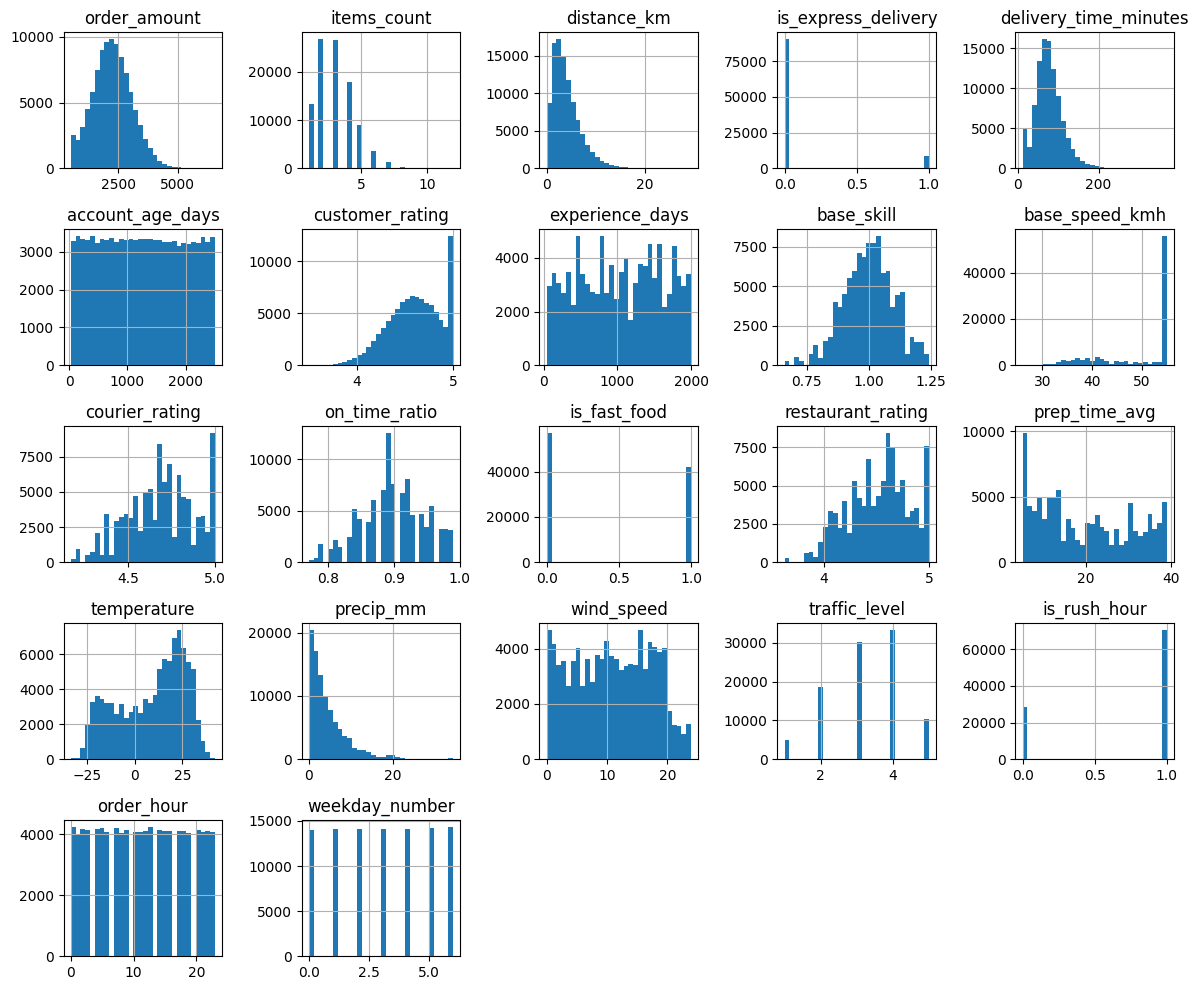

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

cols_to_drop = ['order_id','customer_id','courier_id','restaurant_id',]

# Выбираем только числовые колонки (int64, float64)
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Гистограммы для всех числовых колонок
df[numeric_cols].drop(cols_to_drop, axis=1).hist(figsize=(12, 10), bins=30)
plt.tight_layout()
plt.show()


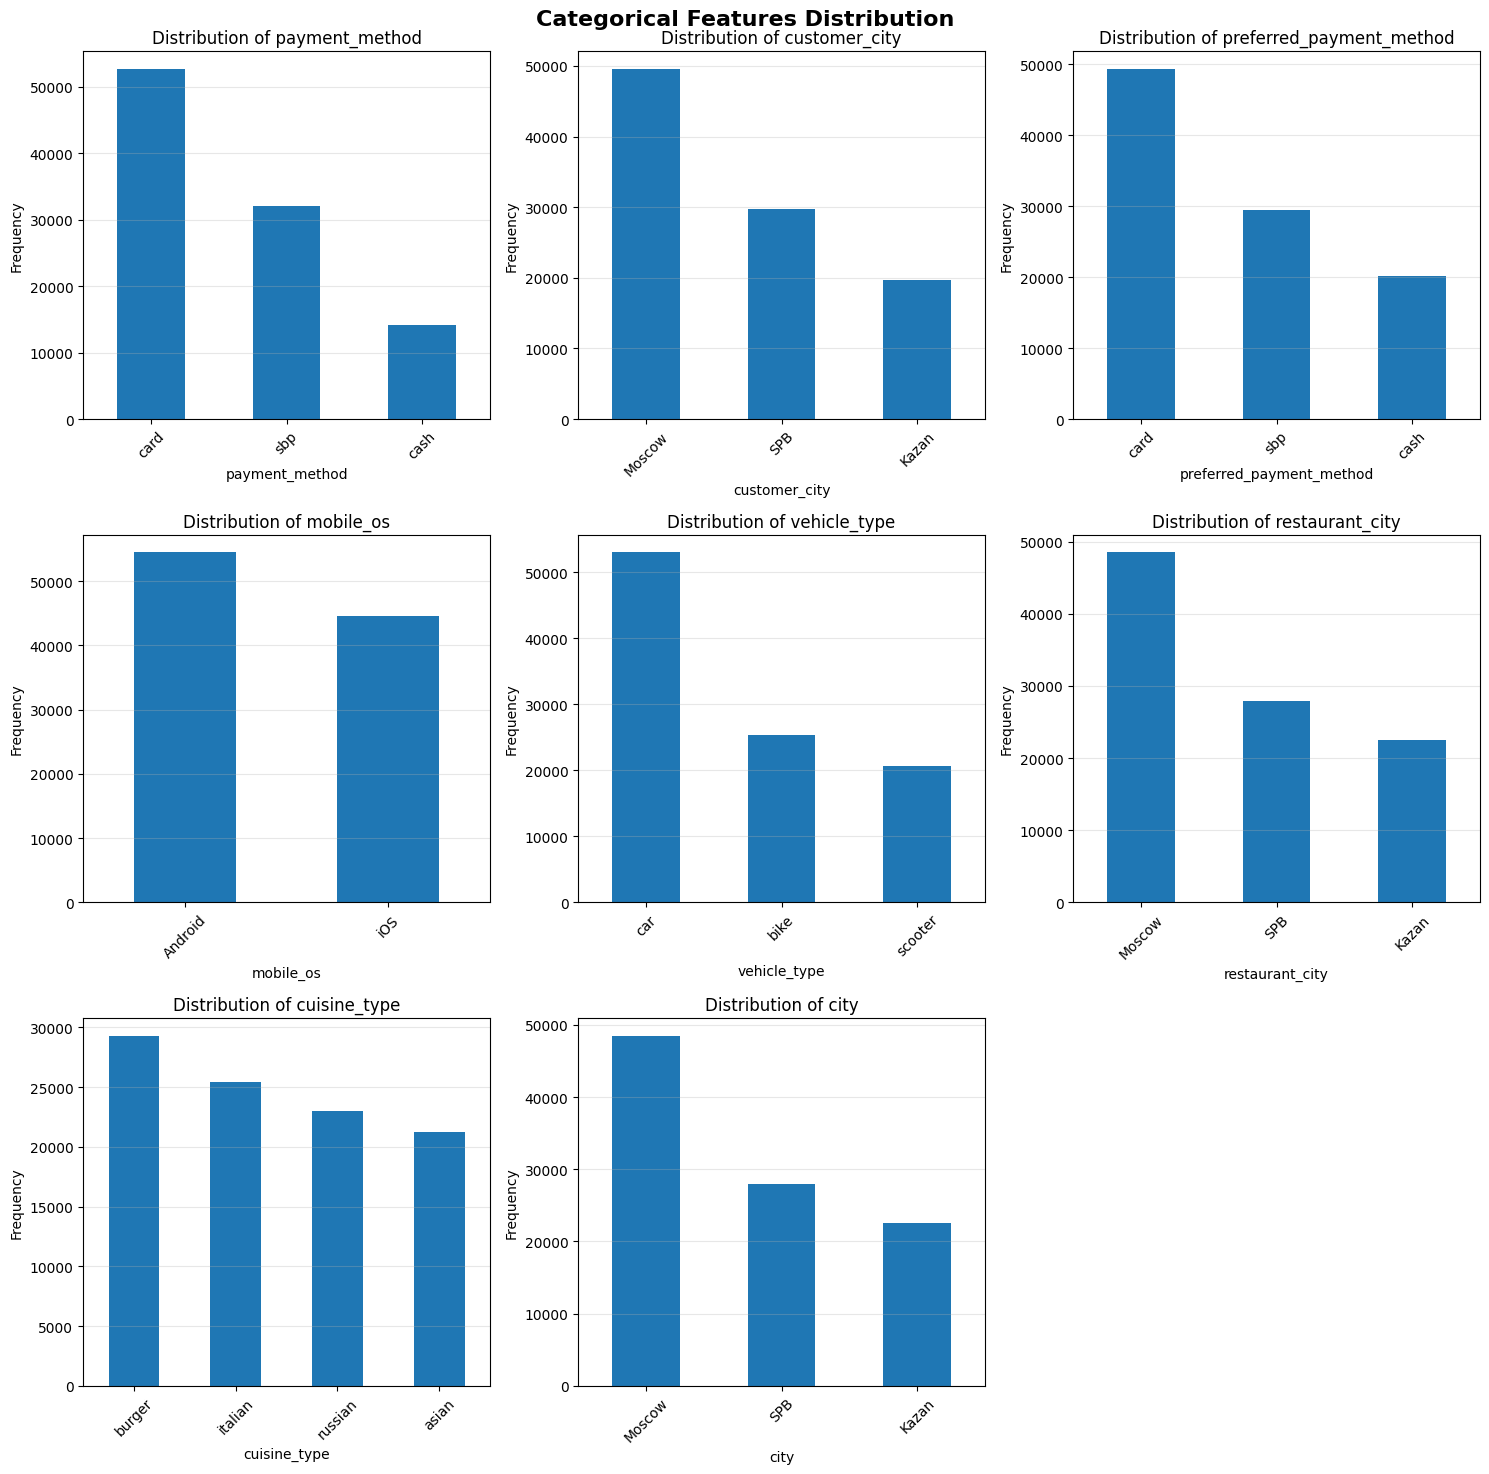

In [ ]:
# Барчарты в сетке
cat_cols = df.select_dtypes(include=['object', 'category']).columns
n_cols = len(cat_cols)

if n_cols > 0:
    # Определяем размер сетки (3 колонки в ряду)
    n_rows = (n_cols + 2) // 3  # округление вверх
    fig, axes = plt.subplots(n_rows, 3, figsize=(15, 5*n_rows))
    axes = axes.flatten()

    for i, col in enumerate(cat_cols):
        if i < len(axes):
            # Строим барчарт
            df[col].value_counts().head(20).plot(kind='bar', ax=axes[i])
            axes[i].set_title(f'Distribution of {col}', fontsize=12)
            axes[i].set_xlabel(col)
            axes[i].set_ylabel('Frequency')
            axes[i].tick_params(axis='x', rotation=45)
            axes[i].grid(axis='y', alpha=0.3)

    # Убираем лишние подграфики
    for i in range(len(cat_cols), len(axes)):
        axes[i].set_visible(False)

    plt.suptitle('Categorical Features Distribution', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()
else:
    print("Нет категориальных признаков")

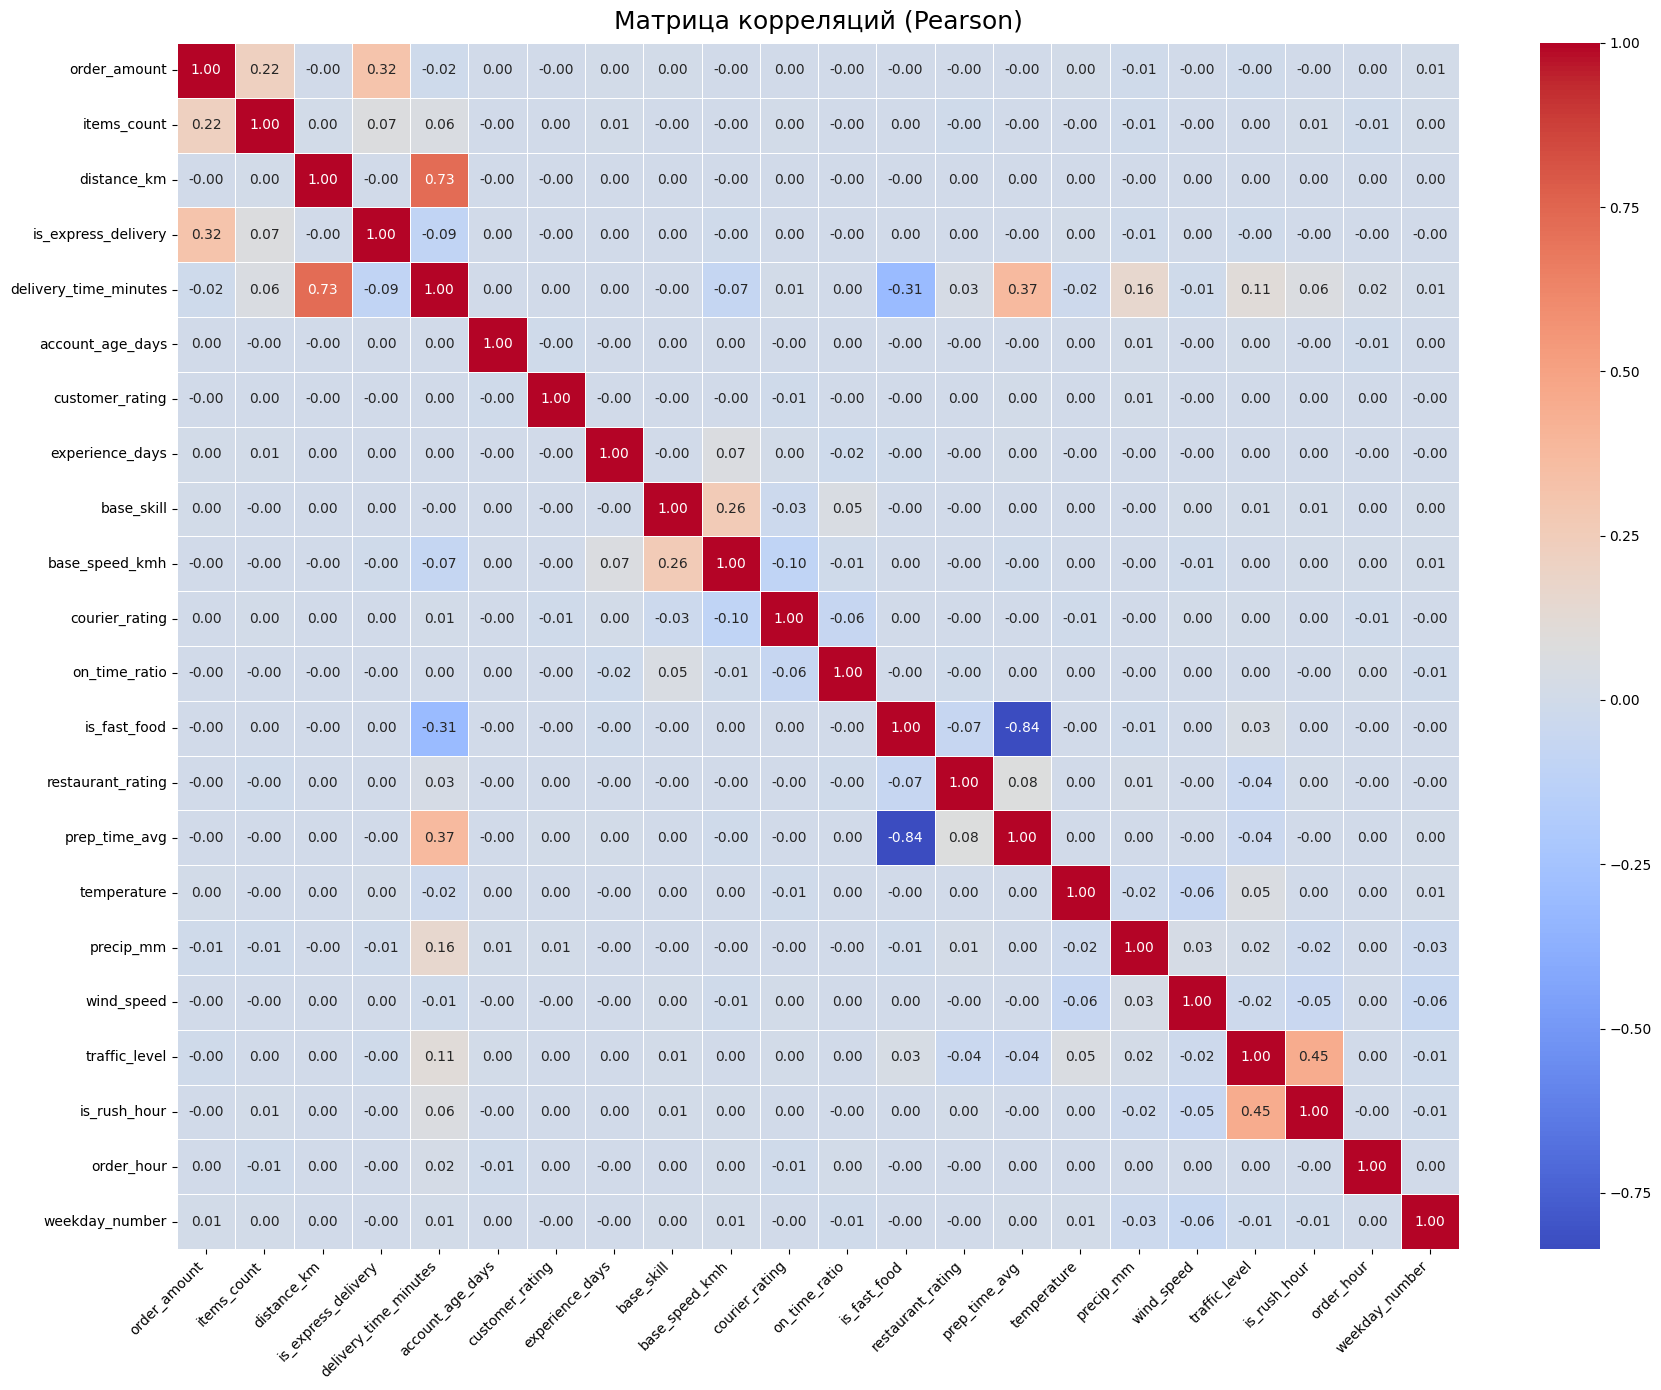

In [ ]:
# Матрица обычных корреляций (Pearson) по числовым признакам
numeric_corr = df[numeric_cols].drop(cols_to_drop, axis=1).corr()

plt.figure(figsize=(18, 14), dpi=100)
sns.heatmap(
    numeric_corr,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 10},
    cmap="coolwarm",
    linecolor="white",
    linewidths=0.5,
)
plt.title("Матрица корреляций (Pearson)", fontsize=18, pad=10)
plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

In [ ]:
pip install phik

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 11.0 MB/s eta 0:00:00


interval columns not set, guessing: ['order_amount', 'items_count', 'distance_km', 'is_express_delivery', 'delivery_time_minutes', 'account_age_days', 'customer_rating', 'experience_days', 'base_skill', 'base_speed_kmh', 'courier_rating', 'on_time_ratio', 'is_fast_food', 'restaurant_rating', 'prep_time_avg', 'temperature', 'precip_mm', 'wind_speed', 'traffic_level', 'is_rush_hour', 'order_hour', 'weekday_number']


<Figure size 1600x900 with 0 Axes>

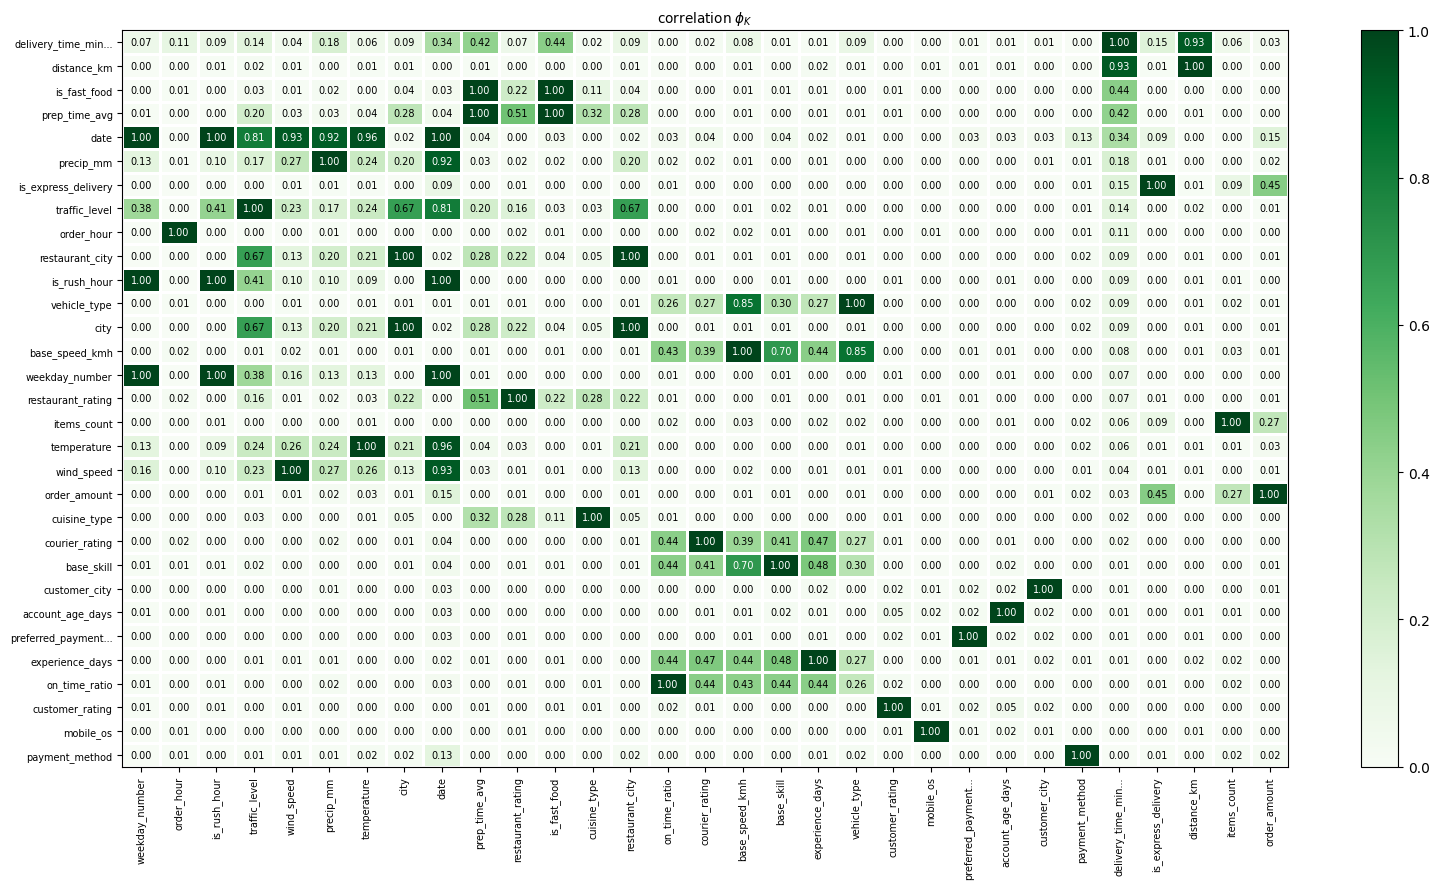

In [ ]:
import phik
from phik.report import plot_correlation_matrix

cols_to_exclude = ['order_id', 'customer_id', 'courier_id', 'restaurant_id',
                   'order_datetime', 'registration_date', 'start_date', 'open_date']

phik_overview = (
    df.drop(cols_to_exclude, axis=1)
      .phik_matrix()
      .round(2)
      .sort_values('delivery_time_minutes')
)

plt.figure(figsize=(16, 9))
plot_correlation_matrix(
    phik_overview.values,
    x_labels=phik_overview.columns,
    y_labels=phik_overview.index,
    vmin=0,
    vmax=1,
    color_map="Greens",
    title=r"correlation $\phi_K$",
    fontsize_factor=0.7,
    figsize=(16, 9),
)
plt.tight_layout()

# 🔧 Этап 3: Предобработка данных
### Критерии оценивания (до 2 баллов):

| Баллы | Требование |
|-------|------------|
| 1 балл | Корректное разделение на train / val / OOT по времени |
| 2 балла | Обработаны пропуски и категориальные признаки |

### 📝 Задание:
На этом этапе нам нужно:
1. Разделить данные с учетом временного порядка (не случайно!)
2. Обработать пропуски в данных
3. Преобразовать категориальные признаки
4. Подготовить данные для обучения моделей (готовые X и y для для всех выборок)

### ⚠️ Важно!
При разделении данных мы **обязаны учитывать время**:
- Обучаем на прошлых данных
- Валидируем на более поздних
- Тестируем (OOT) на самых новых данных

Это имитирует реальную ситуацию, когда модель предсказывает будущее!

In [ ]:
pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.1 MB/s eta 0:00:00


In [ ]:
# проверяем пропуск
df.isnull().sum()[df.isnull().sum() > 0]

,0


In [ ]:
# заполним пропуски temperature
df = df.sort_values(['restaurant_city', 'date'])
df['temperature'] = df.groupby('restaurant_city')['temperature'].transform(lambda x: x.interpolate(method='linear'))
# заполним пропуски precip_mm
df['precip_mm'] = df.groupby('restaurant_city')['precip_mm'].transform(lambda x: x.interpolate(method='linear'))
# Затем заполняем начало группы следующим значением (bfill)
df['precip_mm'] = df.groupby('restaurant_city')['precip_mm'].transform(
    lambda x: x.fillna(method='bfill')
)
df['wind_speed'] = df.groupby('restaurant_city')['wind_speed'].transform(lambda x: x.interpolate(method='linear'))
df['traffic_level'] = df.groupby('restaurant_city')['traffic_level'].transform(lambda x: x.interpolate(method='linear'))

/tmp/ipykernel_1490/4206815931.py:8: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  lambda x: x.fillna(method='bfill')


In [ ]:
target_col = 'delivery_time_minutes'
cols_to_drop.append(target_col)
# что нужно удалить?
# date
# Разделяем по квантилям времени (60% / 20% / 20%)
q60 = df['order_datetime'].quantile(0.60)
q80 = df['order_datetime'].quantile(0.80)

train_df = df[df['order_datetime'] <= q60].copy()
val_df   = df[(df['order_datetime'] > q60) & (df['order_datetime'] <= q80)].copy()
oot_df   = df[df['order_datetime'] > q80].copy()

# Формируем матрицы признаков и целевые переменные
X_train = train_df.drop(cols_to_drop, axis=1)
y_train = train_df[target_col]

X_val = val_df.drop(cols_to_drop, axis=1)
y_val = val_df[target_col]

X_oot = oot_df.drop(cols_to_drop, axis=1)
y_oot = oot_df[target_col]

# Оборачиваем в Pool (CatBoost-формат)
from catboost import CatBoostRegressor, Pool
train_pool = Pool(X_train, label=y_train, cat_features=cat_cols.tolist() )
val_pool   = Pool(X_val,   label=y_val, cat_features=cat_cols.tolist() )
oot_pool   = Pool(X_oot,   label=y_oot, cat_features=cat_cols.tolist() )

На выходе должны быть готовые для обучения данные в виде X_train, X_val, X_oot, y_train, y_val, y_oot

# 🤖 Этап 4: Baseline модель
### Критерии оценивания (до 3 баллов):

| Баллы | Требование |
|-------|------------|
| 1 балл | Обучена базовая модель |
| 2 балла | Выбрана адекватная метрика и оценено качество |
| 3 балла | Есть анализ результатов модели на разных выборках |

### 📝 Задание:
На этом этапе нам нужно:
1. Обучить простую модель
2. Выбрать метрики для оценки качества
3. Оценить модель на train/val/oot
4. Проанализировать результаты и сделать выводы


In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error

# Baseline-модель CatBoost

cb_baseline = CatBoostRegressor(
    iterations=1000,
    depth=6,
    loss_function="RMSE",
    eval_metric="RMSE",
    early_stopping_rounds=100,
    random_state=42,
    verbose=False,
)

cb_baseline.fit(
    train_pool,
    eval_set=val_pool,
    use_best_model=True,
)

# Оценим качество на всех выборках
def evaluate_model(model, train_pool, val_pool, oot_pool, title=""):
    train_pred = model.predict(train_pool)
    val_pred = model.predict(val_pool)
    oot_pred = model.predict(oot_pool)

    train_true = train_pool.get_label()
    val_true   = val_pool.get_label()
    oot_true   = oot_pool.get_label()


    # RMSE
    train_rmse = np.sqrt(mean_squared_error(train_true, train_pred))
    val_rmse = np.sqrt(mean_squared_error(val_true, val_pred))
    oot_rmse = np.sqrt(mean_squared_error(oot_true, oot_pred))

    print(f"RMSE:")
    print(f"  train: {train_rmse:.6f}")
    print(f"  val:   {val_rmse:.6f}")
    print(f"  oot:   {oot_rmse:.6f}")

evaluate_model(cb_baseline, train_pool, val_pool, oot_pool, title="Baseline CatBoost (все признаки)")

RMSE:
  train: 16.285396
  val:   18.436341
  oot:   15.728005


,Feature Id,Importances
0,distance_km,42.816343
1,prep_time_avg,15.839239
2,traffic_level,11.159314
3,precip_mm,6.871995
4,date,5.730427
5,wind_speed,3.071109
6,order_hour,2.787134
7,weekday_number,2.238533
8,temperature,1.901848
9,is_fast_food,1.871957


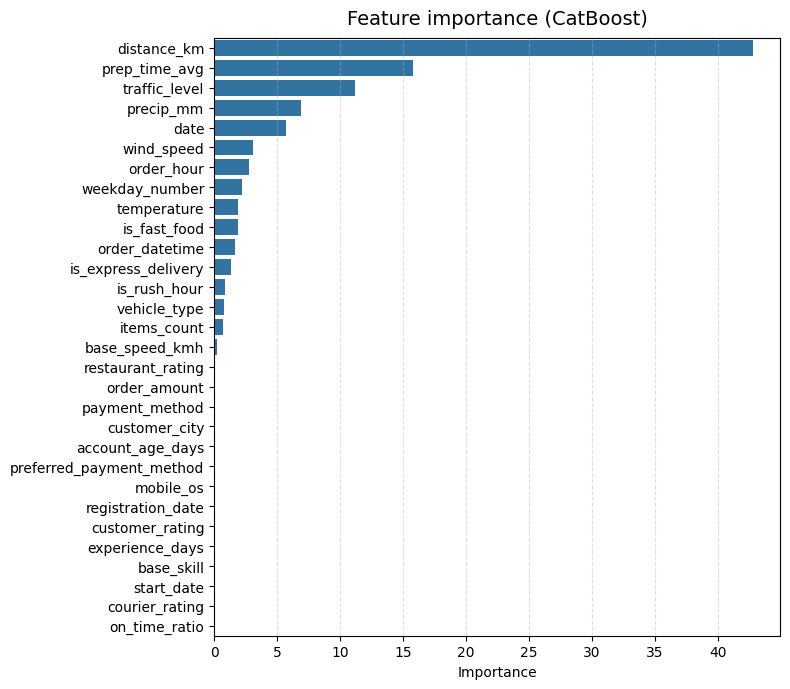

In [ ]:
# Важность признаков по версии CatBoost
# Документация: https://catboost.ai/en/docs/concepts/fstr

fi = cb_baseline.get_feature_importance(prettified=True)
fi = fi.sort_values("Importances", ascending=False).reset_index(drop=True)

display(fi.head(30))

plt.figure(figsize=(8, 7))
sns.barplot(
    data=fi.head(30),
    x="Importances",
    y="Feature Id",
    orient="h",
)
plt.title("Feature importance (CatBoost)", fontsize=14, pad=10)
plt.xlabel("Importance")
plt.ylabel("")
plt.grid(axis="x", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# 🧪 Этап 5: Эксперименты и улучшение модели
### Критерии оценивания (до 4 баллов):

| Баллы | Требование |
|-------|------------|
| 1 балл | Проведён хотя бы один дополнительный эксперимент |
| 2 балла | Хотя бы для одного эксперимента использовался подбор гиперпараметров |
| 3 балла | Использовался отбор признаков |
| 4 балла | Дополнительно осознанно выбрана финальная модель и объяснение - почему именна эта модель|

### 📝 Задание:
На этом этапе нам нужно улучшить baseline модель. Возможные направления:

1. **Новые модели**: попробовать другую модель, например другой градиентный бустинг (XGBoost, LightGBM, CatBoost)
2. **Подбор гиперпараметров**: найти оптимальные параметры для моделей
3. **Отбор признаков**: оставить только самые важные признаки
4. **Комбинации**: использовать лучшие практики из экспериментов

### 📊 Система логирования экспериментов

Поскольку в Colab MLflow недоступен, предлагается создать простую систему логирования в Dataframe.


Либо проводить эксперименты локально с Jupiter + MLFlow и в colab пикрепить скриншоты экспериментов



Пример логирования (простой пример, можно сделать лучше):


```python
import pandas as pd
from datetime import datetime

# Создаем пустой DataFrame для логирования
experiments_log = pd.DataFrame(columns=[
    'experiment_name',      # Название эксперимента
    'model_type',           # Тип модели
    'timestamp',            # Время проведения
    'train_mae',            # Метрика на train
    'val_mae',              # Метрика на валидации
    'oot_mae',              # Метрика на OOT
    'params',               # Параметры модели
    'features_used',        # Использованные признаки
    'comments'              # Комментарии
])

def log_experiment(experiment_name, model_type, model,
                   X_train, y_train, X_val, y_val, X_oot, y_oot,
                   params=None, features_used='all', comments=''):
    """
    Функция для логирования эксперимента
    """
    from sklearn.metrics import mean_absolute_error
    
    # Предсказания
    y_train_pred = model.predict(X_train)
    y_val_pred = model.predict(X_val)
    y_oot_pred = model.predict(X_oot)
    
    # Считаем метрики
    train_mae = mean_absolute_error(y_train, y_train_pred)
    val_mae = mean_absolute_error(y_val, y_val_pred)
    oot_mae = mean_absolute_error(y_oot, y_oot_pred)
    
    # Создаем запись
    new_exp = pd.DataFrame({
        'experiment_name': [experiment_name],
        'model_type': [model_type],
        'timestamp': [datetime.now().strftime('%Y-%m-%d %H:%M:%S')],
        'train_mae': [round(train_mae, 3)],
        'val_mae': [round(val_mae, 3)],
        'oot_mae': [round(oot_mae, 3)],
        'params': [str(params) if params else 'default'],
        'features_used': [features_used],
        'comments': [comments]
    })
    
    # Добавляем в общий лог
    global experiments_log
    experiments_log = pd.concat([experiments_log, new_exp], ignore_index=True)
    
    print(f"✅ Эксперимент '{experiment_name}' залогирован")
    print(f"   Val MAE: {val_mae:.3f}, Val R2: {val_r2:.4f}")
    
    return val_mae

# Пример использования:
"""
# Обучаем модель
rf_model = RandomForestRegressor(n_estimators=100)
rf_model.fit(X_train, y_train)

# Логируем эксперимент
log_experiment(
    experiment_name='01_rf_baseline',
    model_type='RandomForest',
    model=rf_model,
    X_train=X_train, y_train=y_train,
    X_val=X_val, y_val=y_val,
    X_oot=X_oot, y_oot=y_oot,
    params={'n_estimators': 100},
    features_used='all_features',
    comments='Первый эксперимент'
)

# Просмотр лога
print(experiments_log)

# Сохранение в CSV
experiments_log.to_csv('experiments_log.csv', index=False)

# Поиск лучшей модели
best_model = experiments_log.loc[experiments_log['val_mae'].idxmin()]
print(f"\nЛучшая модель: {best_model['experiment_name']}")
print(f"Лучший MAE: {best_model['val_mae']}")
"""
```



In [ ]:
# ваш код

На выходе должна быть выбрана финальная модель

# 🔍 Этап 6: Интерпретация модели
### Критерии оценивания (до 2 баллов):

| Баллы | Требование |
|-------|------------|
| 1 балл | Построены графики важности признаков |
| 2 балла | Объяснено влияние ключевых признаков |

### 📝 Задание:
На этом этапе нам нужно:
1. Проанализировать, какие признаки больше всего влияют на время доставки
2. Визуализировать важность признаков
3. Объяснить, как каждый ключевой признак влияет на целевую переменную
4. Сделать бизнес-выводы на основе интерпретации

In [ ]:
# ваш код

# 📊 Этап 7: Мониторинг и анализ сдвига данных
### Критерии оценивания (1 балл):

| Баллы | Требование |
|-------|------------|
| 1 балл | На OOT выборке проанализирован сдвиг данных (data drift) |

### 📝 Задание:
На этом этапе нам нужно:
1. Сравнить распределения признаков в обучающей и OOT выборках
2. Выявить признаки, в которых произошел сдвиг
3. Оценить, как сдвиг данных повлиял на качество модели
4. Предложить стратегии мониторинга и обновления модели

In [ ]:
# Ваш код


# 🚀 Этап 8: Деплой модели (Бонусный этап — 7 баллов)

### 📌 Важно!
Этот этап **необязательный**, но даёт возможность получить дополнительные баллы.  
Вы можете выбрать **один** из двух вариантов деплоя. Любой выбранный вариант при полном и качественном выполнении оценивается в **7 баллов**.

**Исходные данные:** у вас уже есть обученная финальная модель и готовая преподготовка данных (из этапов 3–5). В этом задании **не нужно заново обучать модель** — только развернуть её для получения предсказаний.

---

## 🔹 Вариант 1. MaaS (Model-as-a-Service) через FastAPI

**Цель:** создать микросервис на FastAPI, который принимает данные заказа в JSON и возвращает предсказанное время доставки.

### Критерии оценки (7 баллов) - по баллу за каждый пункт

| Баллы | Требование |
|-------|------------|
| 1 | Репозиторий имеет правильную структуру (папки `models/`, `src/`, `tests/`, файлы `requirements.txt`, `README.md`, `.gitignore`) |
| 1 | В папке `models/` лежит сохранённая модель (`model.joblib` или `.pkl`) и, если необходимо, препроцессор |
| 1 | В `src/` реализованы модули: `preprocessing.py` (функции преобразования данных) - если нобходимо, `inference.py` (загрузка модели и предсказание), `app.py` (FastAPI приложение с эндпоинтами) |
| 1 | Эндпоинт `/predict` (POST) принимает JSON, валидирует данные через Pydantic, возвращает предсказание в формате `{"prediction": float}` |
| 1 | Эндпоинт `/health` (GET) возвращает статус сервиса (например, `{"status": "ok"}`) |
| 1 | Код покрыт обработкой ошибок (невалидные данные, отсутствие признаков) и логированием |
| 1 | Написан подробный `README.md` с инструкцией по установке, запуску и примером запроса через `curl` |

**Структура репозитория (пример):**



```
delivery-mas/
├── models/
│   └── model.joblib              # обученная модель (и препроцессор, если нужно)
├── src/
│   ├── __init__.py
│   ├── app.py                     # FastAPI приложение
│   ├── inference.py                # загрузка модели и функция predict
│   └── preprocessing.py            # функции подготовки данных
├── tests/                          # (опционально) тесты
├── requirements.txt
├── README.md
└── .gitignore
```


**Запуск (без Docker):**
```bash
pip install -r requirements.txt
uvicorn src.app:app --reload
```

**Пример запроса:**
```bash
curl -X POST "http://localhost:8000/predict" \
  -H "Content-Type: application/json" \
  -d '{
    "distance_km": 3.5,
    "items_count": 2,
    "order_amount": 1540,
    "customer_city": "Moscow",
    "vehicle_type": "car",
    "prep_time_avg": 15,
    "traffic_level": 3,
    "is_express_delivery": 0
  }'
```

**Примечание:** Docker не обязателен, но если вы его добавите (Dockerfile, docker-compose), это будет плюсом к качеству, но не влияет на баллы (7 баллов уже максимум).

[Пример MaaS, который мы разбирали на курсе](https://github.com/totiela/sim-ds-model-as-a-service)

---

## 🔹 Вариант 2. Batch‑scoring через Airflow

**Цель:** реализовать пайплайн пакетного скоринга новых заказов с помощью Apache Airflow. Модель применяется к данным из `data/input/`, результаты сохраняются в `data/output/`.

### Критерии оценки (7 баллов) - по баллу за каждый пункт

| Баллы | Требование |
|-------|------------|
| 1 | Репозиторий имеет структуру, аналогичную примеру (папки `dags/`, `data/`, `models/`, `config/`, `docker-compose.yaml`) |
| 1 | В папке `models/` лежит сохранённая модель (и препроцессор) |
| 1 | Создан DAG-файл (`dags/delivery_scoring.py`), который реализует следующий pipeline: загрузка новых данных из `data/input/`, применение модели, сохранение результатов в `data/output/` |
| 1 | DAG содержит корректные операторы (например, `PythonOperator`) и настроен на запуск с определённой периодичностью (или можно запускать вручную) |
| 1 | Обработка ошибок: DAG не падает при отсутствии файлов, логирует проблемы, пропускает некорректные строки |
| 1 | Настроен `docker-compose.yaml` для поднятия Airflow (PostgreSQL + Scheduler + Webserver) с пробросом папок `dags/`, `data/`, `logs/`, `plugins/` |
| 1 | Написан подробный `README.md` с инструкцией по запуску Airflow через Docker Compose, описанием структуры и примером работы DAG |

**Структура репозитория (пример):**
```
delivery-airflow/
├── dags/
│   └── delivery_scoring.py        # DAG для пакетного скоринга
├── data/
│   ├── input/                      # сюда кладём новые CSV с заказами
│   └── output/                     # сюда DAG сохраняет результаты с предсказаниями
├── models/
│   └── model.joblib                 # обученная модель
├── logs/                            # логи Airflow (будут созданы автоматически)
├── plugins/                         # (пусто, но нужно для монтирования)
├── config/                           # (опционально) airflow.cfg
├── docker-compose.yaml               # запуск всех сервисов Airflow
├── requirements.txt                  # зависимости (airflow, pandas, scikit-learn, joblib)
├── README.md
└── .gitignore
```

**Пример работы:**
1. Пользователь кладёт файл `new_orders_20250220.csv` в `data/input/`.
2. DAG запускается (по расписанию или вручную через UI).
3. DAG читает файл, применяет модель, сохраняет результат в `data/output/` с тем же именем + суффикс `_predicted`.
4. Все действия логируются в Airflow.

**Запуск Airflow:**
```bash
docker-compose up -d
# через минуту заходим в веб-интерфейс http://localhost:8080
# (логин/пароль по умолчанию: airflow/airflow)
```

[Пример Airflow, который мы разбирали на курсе](https://github.com/totiela/simulator_ds_airflow)

---

## 📋 Общие требования для обоих вариантов

- Код должен быть написан аккуратно, с комментариями, соблюдением PEP8.
- Все зависимости указаны в `requirements.txt` (или можно использовать `uv`)
- `README.md` содержит:
  - Описание выбранного подхода.
  - Инструкцию по установке и запуску.
  - Примеры входных данных и результатов.
- Репозиторий публичный, ссылка присылается на проверку.

---

## 💡 Что важно помнить

- Финальная модель уже готова из прошлого этапа, обучать заново **не нужно**.
- Для MaaS не требуется Docker, но он допускается.
- Для Airflow обязательно использование `docker-compose.yaml` для простоты развёртывания
- Все файлы, создаваемые в процессе работы (например, предсказания), должны сохраняться в соответствующие папки внутри проекта.
- Структуры проектов - это пример, вы можете сделать еще лучше!

---

## ✅ Результат
В качестве результата ожидается ссылка на ваш репозиторий на github (**убедитесь, что у репозитория доступ публичный**)



In [ ]:
# сюда, ниже прикрепите вашу ссылку на github


Для того чтобы сдать проект - нужно в рецензию к заданию вставить ссылку на ваш заполненный colab ноутбук, а также рекомендуется указать ваш телеграм для обратной связи.

 **Убедитесь, что вы дали к ноутбуку открытый доступ - инструкция ниже!**

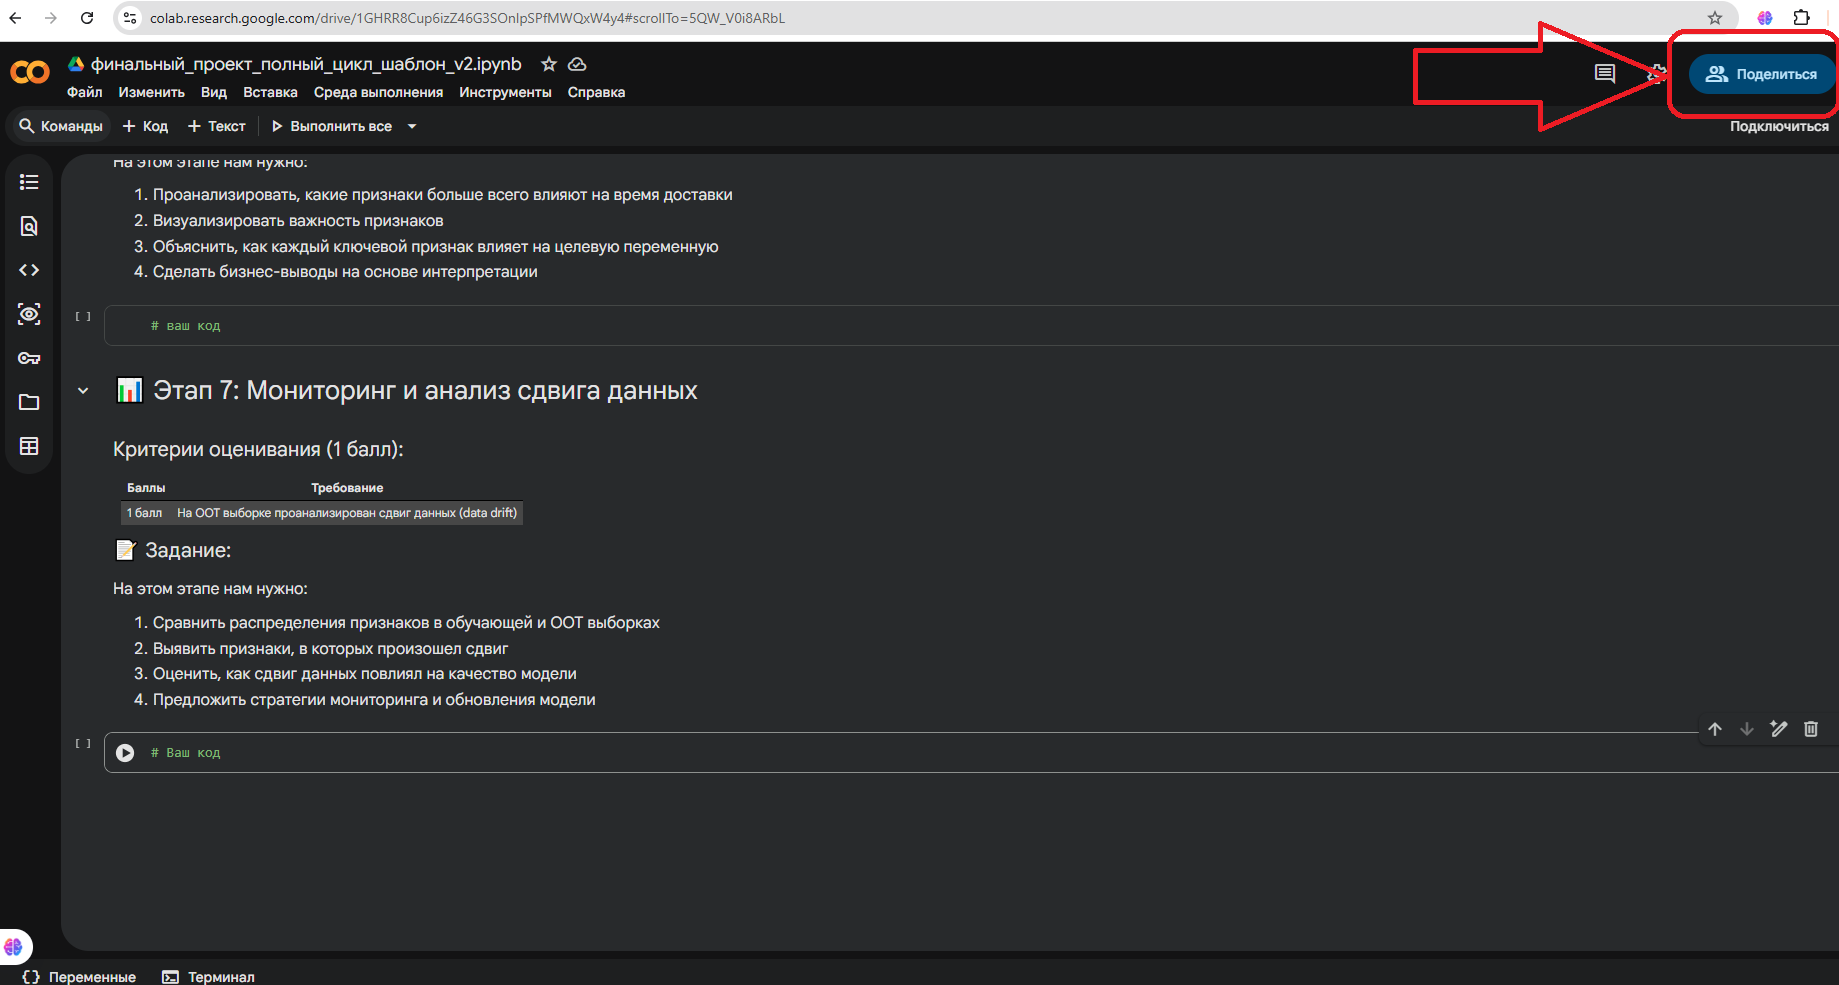

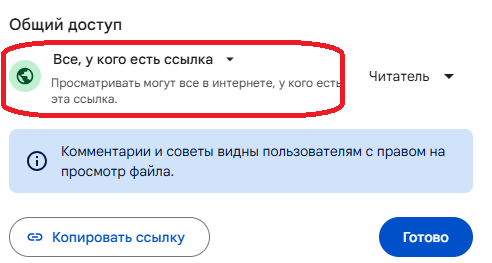